# Triangle plots for subluminal chains, constant $c_s^2$, with CMB lensing and DES

In [3]:
import numpy as np
import getdist
from getdist import plots

import utils

In [8]:
indices = list(range(81, 83)) + [76, 84, 98, 99, 100]
chains = {}
for i in indices:
    chains[i] = utils.load_chain(i, burn_in=0.4, smooth_2D=0.35, smooth_1D=0.35)

../chains/MCMC100/MCMC100.1.txt
../chains/MCMC100/MCMC100.2.txt
../chains/MCMC100/MCMC100.3.txt
../chains/MCMC100/MCMC100.4.txt
Removed no burn in


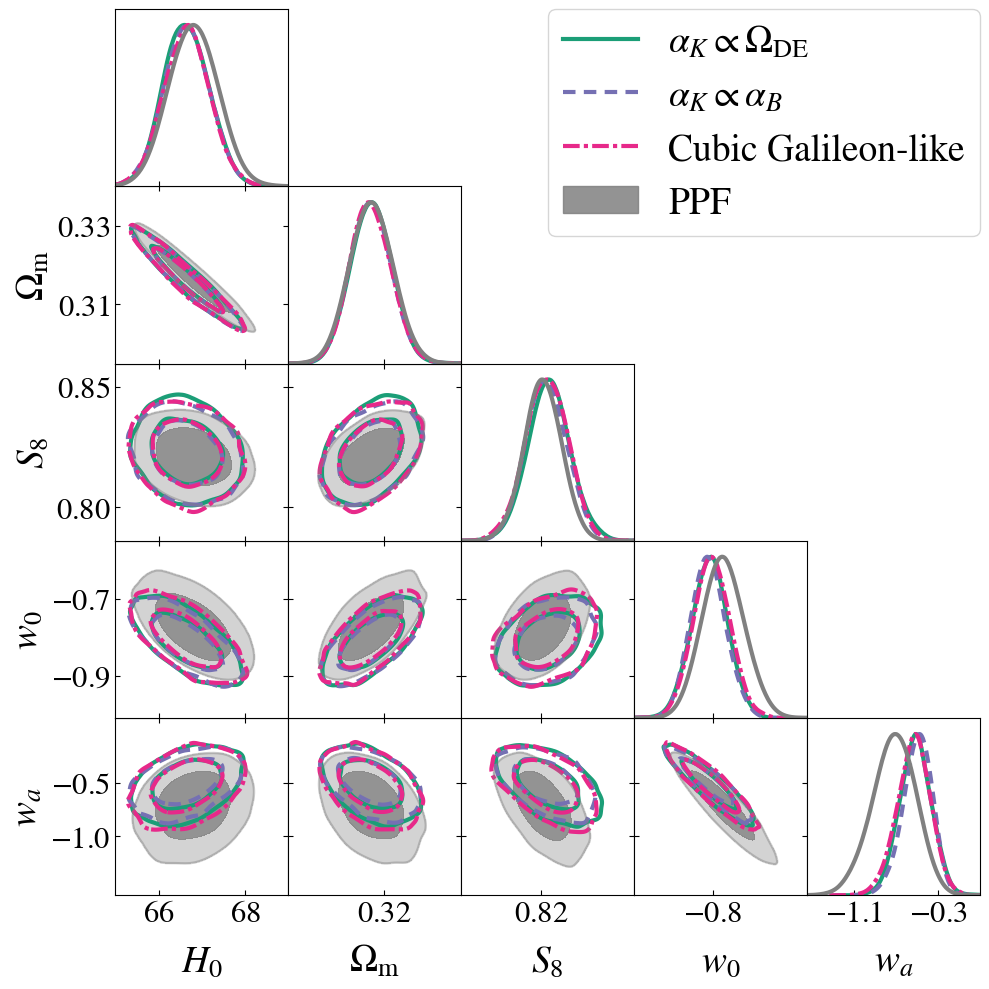

In [9]:
p = plots.get_subplot_plotter()
p.settings.axes_fontsize=25
p.settings.axes_labelsize=30
p.settings.legend_fontsize=30
p.triangle_plot(
    [chains[98], chains[100], chains[82], chains[76]],
    ["H0", "omegam", "S8", "w", "wa"],
    filled=[False, False, False, True],
    contour_colors=[utils.colors[0], utils.colors[2], utils.colors[3], "gray"],
    contour_lws=3,
    contour_ls=["-", "--", "-.", "-"],
    legend_labels=["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like", "PPF"],
    legend_loc="upper right",
    param_limits={"w": [-1.01, -0.55], "wa": [-1.55, 0.1], "H0": [65, 69], "omegam": [0.295, 0.34]}
)
p.fig.savefig("plots/triangle_ds2_subluminal_mg.pdf", bbox_inches="tight")

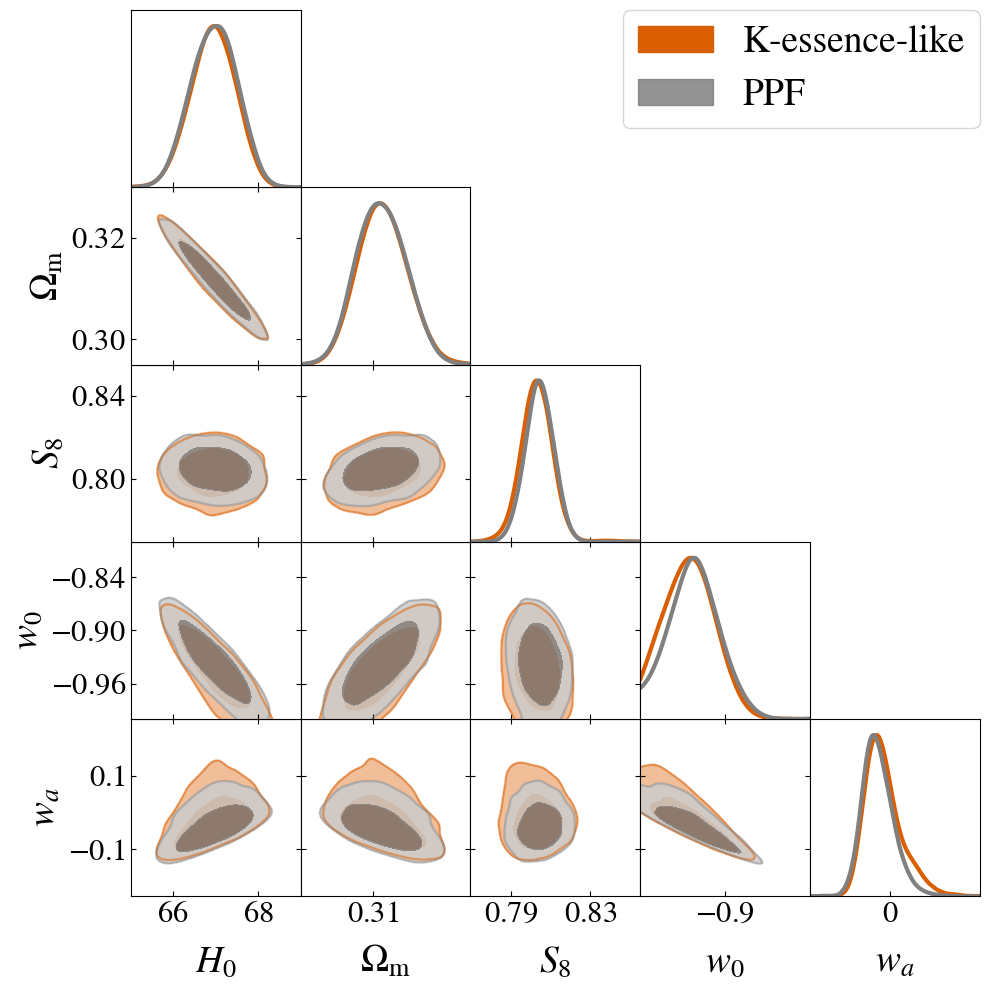

In [13]:
p = plots.get_subplot_plotter()
p.settings.axes_fontsize=25
p.settings.axes_labelsize=30
p.settings.legend_fontsize=30
p.triangle_plot(
    [chains[99], chains[84]],
    ["H0", "omegam", "S8", "w", "wa"],
    filled=[True, True],
    contour_colors=[utils.colors[1], "gray"],
    contour_lws=3,
    contour_ls="-",
    legend_labels=["K-essence-like", "PPF"],
    legend_loc="upper right",
    param_limits={"w": [-1, -0.8], "H0": [65, 69], "omegam": [0.295, 0.33]}
)
# p.fig.text(0.3, 1.01, "Data: Planck + DESI + DES-Dovekie", fontsize=20)
p.fig.savefig("plots/triangle_ds2_subluminal_mg_kessence.pdf", bbox_inches="tight")

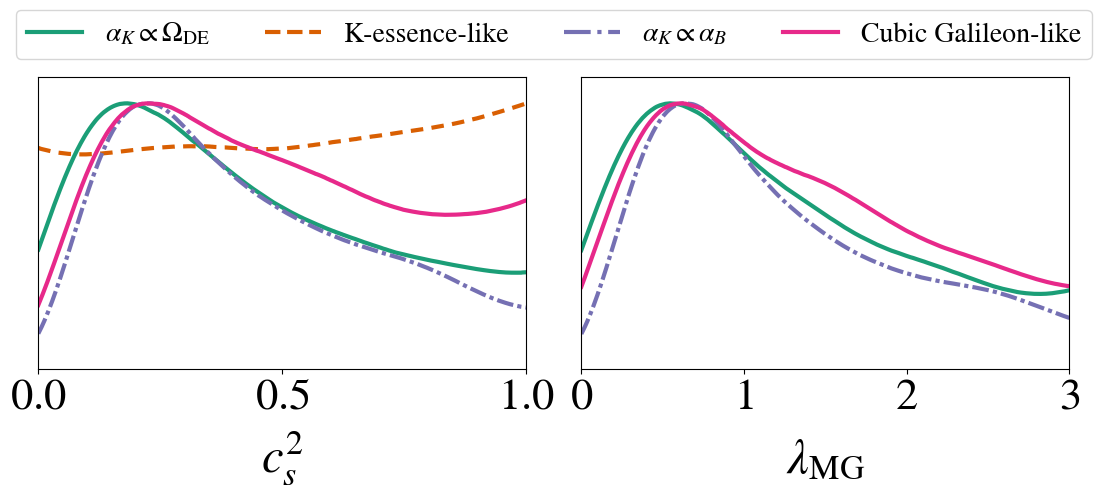

In [10]:
p = plots.get_subplot_plotter(width_inch=11, subplot_size_ratio=4/5)
p.settings.axes_fontsize=32
p.settings.axes_labelsize=35
p.settings.legend_fontsize=30
labels = ["$\\alpha_K \\propto \\Omega_\\mathrm{DE}$", "K-essence-like", "$\\alpha_K \\propto \\alpha_B$", "Cubic Galileon-like"]
p.plots_1d(
    [chains[98], chains[99], chains[100], chains[82]],
    ["cs2_0", "alpha_K_0"],
    colors=utils.colors,
    lws=3,
    ls=["-", "--", "-.", "-"],
    nx=2,
    legend_labels=[],
    param_limits={"w": [-1.01, -0.55], "wa": [-1.55, 0.1], "H0": [65, 69], "omegam": [0.295, 0.34]}
)

from matplotlib.lines import Line2D

handles = [
    Line2D([], [], linewidth=3, linestyle="-",  color=utils.colors[0]),
    Line2D([], [], linewidth=3, linestyle="--", color=utils.colors[1]),
    Line2D([], [], linewidth=3, linestyle="-.", color=utils.colors[2]),
    Line2D([], [], linewidth=3, linestyle="-",  color=utils.colors[3]),
]

# place legend relative to the figure (x,y in figure coordinates)
p.fig.legend(handles, labels,
             loc="upper center",
             ncol=4,
             fontsize=20,
             bbox_to_anchor=(0.508, 1.15),
             bbox_transform=p.fig.transFigure,
             frameon=True)

p.fig.savefig("plots/lambda_mg_cs2_subluminal_ds2.pdf", bbox_inches="tight")

In [12]:
# Getting numbers
for i, chain in chains.items():
    try: print(f"{i}: {chain.getInlineLatex('H0')}, {chain.getInlineLatex('ns')}, {chain.getInlineLatex('omegam')}, {chain.getInlineLatex('S8')}, {chain.getInlineLatex('w')}, {chain.getInlineLatex('wa')}, {chain.getInlineLatex('cs2_0', limit=2)}")
    except Exception: print(f"{i}: {chain.getInlineLatex('H0')}, {chain.getInlineLatex('ns')}, {chain.getInlineLatex('omegam')}, {chain.getInlineLatex('S8')}, {chain.getInlineLatex('w')}, {chain.getInlineLatex('wa')}")

81: H_0 = 66.63\pm 0.50, n_\mathrm{s} = 0.9716^{+0.0028}_{-0.0032}, \Omega_\mathrm{m} = 0.3167\pm 0.0052, S_8 = 0.8209^{+0.0084}_{-0.0074}, w_0 = -0.817\pm 0.043, w_a = -0.48^{+0.13}_{-0.11}, c_s^2 = 0.45^{+0.49}_{-0.39}
82: H_0 = 66.65\pm 0.54, n_\mathrm{s} = 0.9714\pm 0.0032, \Omega_\mathrm{m} = 0.3164\pm 0.0054, S_8 = 0.8224\pm 0.0091, w_0 = -0.804\pm 0.050, w_a = -0.53^{+0.17}_{-0.15}, c_s^2 = ---
76: H_0 = 66.82\pm 0.72, n_\mathrm{s} = 0.9694\pm 0.0035, \Omega_\mathrm{m} = 0.3165\pm 0.0063, S_8 = 0.8208\pm 0.0082, w_0 = -0.775\pm 0.073, w_a = -0.72\pm 0.23, c_s^2 = ---
84: H_0 = 66.96\pm 0.56, n_\mathrm{s} = 0.9736\pm 0.0033, \Omega_\mathrm{m} = 0.3118^{+0.0049}_{-0.0055}, S_8 = 0.8043\pm 0.0074, w_0 = -0.936\pm 0.030, w_a = -0.034^{+0.036}_{-0.049}, c_s^2 = ---
98: H_0 = 66.64\pm 0.53, n_\mathrm{s} = 0.9709\pm 0.0033, \Omega_\mathrm{m} = 0.3166\pm 0.0053, S_8 = 0.8233\pm 0.0091, w_0 = -0.809\pm 0.049, w_a = -0.52\pm 0.16, c_s^2 = ---
99: H_0 = 66.94\pm 0.53, n_\mathrm{s} = 0.9730